# 问题二 求解讲解：跨维度数据融合与广义标度律

**任务拆解**（题面四项递进）：

1. 拟合只含 $N,D$ 的经典标度律（B1 为主拟合数据）；
2. 判定附件 B 质量字段 `Q_score` 的方向（是"质量"还是"难度/噪声"）；
3. 建立同时含 $N,D,Q,\bm p$ 的广义标度律——题面建议"当教材趋于完美时，新公式退化为经典形式"；
4. 分析边际效用与弹性，讨论领域间的替代/互补，并推导**质量与参数规模可相互替代的条件**。

**数据独立性提醒**：附件 A 与 B 是相互独立的实验，但都以交叉熵损失为可观测量，因此要先提出可检验的假设（本文用"质量决定不可约损失下限"）把它们统一到同一模型；B6–B8 是基于真实数据校准的**半合成**补充集，可用于补充分析但不得表述为直接实验观测，且须说明局限。

> **运行说明**
> - 本 notebook 放在 `求解/问题X/` 目录下，请在该目录下打开；`_common.py` 会自动定位附件目录、输出目录与字体。
> - 依赖：`numpy`、`pandas`、`scipy`、`matplotlib`（无需 GPU）。
> - 单元已带上次真实运行的输出，直接看即可；想复现就从上到下 Run All。
> - 结果 CSV 写入 `结果/`，图片写入 `图片/`。

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')
# 让本 notebook 能 import 到 求解/_common.py（notebook 位于 求解/问题X/ 下）
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
from _common import *   # noqa: F401,F403

# 在 Jupyter 中运行时，让 save_fig 除保存文件外也把图片内联显示出来。
# 注意必须改 _common 模块的属性：脚本头部还会再执行一次 `from _common import *`，
# 只改本地名字会被覆盖。
try:
    from IPython.display import display as _ipy_display, Image as _ipy_Image
    import _common as _cm
    _orig_save_fig = _cm.save_fig
    def save_fig(fig, name_cn, dpi=300):
        _orig_save_fig(fig, name_cn, dpi)
        try:
            _ipy_display(_ipy_Image(filename=os.path.join(_cm.FIG_DIR, name_cn + '.png')))
        except Exception:
            pass
    _cm.save_fig = save_fig
except Exception:
    pass   # 非 Jupyter 环境（直接跑脚本）不需要内联显示

print('附件目录:', DATA_DIR)
print('结果目录:', OUT_DIR)
print('图片目录:', FIG_DIR)


附件目录: C:\Users\qq190\Desktop\第二十三届中国研究生数学建模竞赛 - 中文题目\中文题目\F题\real_attachments
结果目录: C:\Users\qq190\Desktop\研赛（华为杯）f题\研赛（华为杯）_2026-09-23_08-27-48\求解\问题二\结果
图片目录: C:\Users\qq190\Desktop\研赛（华为杯）f题\研赛（华为杯）_2026-09-23_08-27-48\求解\问题二\图片


### 准备：模块头与公共工具函数

这一段是脚本自己的模块头（导入 + `save_csv_safe` 等公共小工具）。notebook 环境下 `__file__` 不存在，
因此原来那行 `sys.path.insert(... __file__ ...)` 已在上面的第 1 个单元用等价方式取代。

> 小技巧：`save_csv_safe` 会在目标 CSV 被 Excel 等程序占用时自动改存为 `*_new.csv`，保证整条流水线不中断。

In [2]:
# -*- coding: utf-8 -*-
"""
问题二：跨维度数据融合与广义标度律
数据：附件 B（B1 主拟合；B2/B3 族外与轨迹验证；B4/B5 跨族与文献验证；
      B6/B7 质量 Q；B8 大规模矩阵（方向异常，仅作可信度边界警示）；B9/B10 百亿参数以上外推）
模型：经典 L = E + A N^-a + B D^-b
      广义 L = E + A N^-a + B D^-b + C (1-Q)^g（Q=1 退化为经典形式）
输出：图片到 图片/，结果 CSV 到 结果/，参数共享至 求解/广义标度律参数.csv
"""
import sys, os, glob
# （sys.path 已在第 1 个代码单元中设置，notebook 里不需要 __file__）
from _common import *  # noqa: F401,F403
from scipy.optimize import least_squares

DATA = data_path

def save_csv_safe(df, name_cn):
    p = os.path.join(OUT_DIR, name_cn)
    try:
        df.to_csv(p, index=False, encoding='utf-8-sig')
    except PermissionError:
        alt = p.replace('.csv', '_new.csv')
        df.to_csv(alt, index=False, encoding='utf-8-sig')
        print('  ! %s 被占用，已改存为 %s' % (name_cn, os.path.basename(alt)))

pythia = pd.read_csv(DATA('pythia_training_log_existing.csv'))
cerebras = pd.read_csv(DATA('cerebras_training_log.csv'))
baseline = pd.read_csv(DATA('scaling_baseline.csv'))
published = pd.read_csv(DATA('published_scaling_data.csv'))
nq6 = pd.read_csv(DATA('supplementary_NQ_experiment.csv'))
nq7 = pd.read_csv(DATA('supplementary_NQ_experiment_expanded.csv'))
nq8 = pd.read_csv(DATA('supplementary_NQ_experiment_large.csv'))
large_models = pd.read_csv(DATA('supplementary_large_models.csv'))
large_loss = pd.read_csv(DATA('supplementary_large_baseline.csv'))
traj_files = sorted(glob.glob(os.path.join(DATA_DIR, 'B_scaling_laws',
                                           'training_trajectories', '*.csv')))

N_p = pythia.N_params_B.to_numpy(float)
D_p = pythia.D_tokens_B.to_numpy(float)
L_p = pythia.val_loss.to_numpy(float)


## 第 1 步：经典标度律（B1 主拟合 + 模型留出验证）

$$L(N,D)=E+\frac{A}{N^{\alpha}}+\frac{B}{D^{\beta}}$$

三点做法说明：

1. **在原函数上做非线性最小二乘，而不是先做双对数线性化**——线性化会把不可约损失 $E$ 这个常数项吃掉，产生系统偏置。
2. 用 `loss='soft_l1'` 稳健损失，降低个别检查点的杠杆效应。
3. **必须做留出验证**：用 4 个最小模型拟合、预测另外 4 个更大模型。因为 B1 是同一族模型的训练轨迹，直接报 $R^2$ 会虚高。

> 提醒：算完会发现 B1 的拟合残差标准差只有 $10^{-4}$ 量级，而损失标准差是 0.34——该附件几乎是 $(N,D)$ 的无噪声函数。**这里的极高 $R^2$ 只能证明函数形式自洽，不能替代外部验证**，真正的泛化证据来自后面 B4/B5 的分层验证。

In [3]:
# ============ 1. 经典标度律（B1 主拟合 + 模型留出验证） ============
def classic(par, N, D):
    E, A, a, B, b = par
    return E + A * N ** (-a) + B * D ** (-b)

r0 = least_squares(lambda p: classic(p, N_p, D_p) - L_p, [1.7, .4, .33, 1.2, .28],
                   bounds=([0, 1e-8, .01, 1e-8, .01], [5, 1e3, 2, 1e3, 2]),
                   loss='soft_l1', f_scale=.05, max_nfev=40000)
E0, A0, a0, B0, b0 = r0.x
Lph = classic(r0.x, N_p, D_p)
R2_cls = 1 - np.sum((L_p - Lph) ** 2) / np.sum((L_p - L_p.mean()) ** 2)
RMSE_cls = float(np.sqrt(np.mean((L_p - Lph) ** 2)))

Ns = sorted(pythia.N_params_B.unique())
tr_m = pythia[pythia.N_params_B.isin(Ns[:4])]
te_m = pythia[pythia.N_params_B.isin(Ns[4:])]
rh = least_squares(lambda p: classic(p, tr_m.N_params_B.values, tr_m.D_tokens_B.values)
                   - tr_m.val_loss.values, [1.7, .4, .33, 1.2, .28],
                   bounds=([0, 1e-8, .01, 1e-8, .01], [5, 1e3, 2, 1e3, 2]),
                   loss='soft_l1', f_scale=.05, max_nfev=40000)
hp = classic(rh.x, te_m.N_params_B.values, te_m.D_tokens_B.values)
ym = te_m.val_loss.values
hold = {'留出R2': 1 - np.sum((ym - hp) ** 2) / np.sum((ym - ym.mean()) ** 2),
        '留出RMSE': float(np.sqrt(np.mean((ym - hp) ** 2))),
        '留出MAPE_%': float(np.mean(np.abs(ym - hp) / ym) * 100)}

print('=== 1. 经典标度律（B1 Pythia, n=%d）===' % len(pythia))
print('  E=%.4f A=%.4f alpha=%.4f B=%.4f beta=%.4f' % (E0, A0, a0, B0, b0))
print('  拟合 R2=%.8f  RMSE=%.6f  MAPE=%.4f%%' % (
    R2_cls, RMSE_cls, np.mean(np.abs(L_p - Lph) / L_p) * 100))
print('  留出验证（4 小模型 -> 4 大模型）：R2=%.8f RMSE=%.6f MAPE=%.4f%%' % (
    hold['留出R2'], hold['留出RMSE'], hold['留出MAPE_%']))
print('  提示：B1 拟合残差标准差仅 %.5f（损失标准差 %.4f），说明该附件近乎无观测噪声，'
      '其上高 R2 只能确认函数形式自洽，不能替代外部验证。' % (
          float(np.std(L_p - Lph)), float(np.std(L_p))))
save_csv_safe(pd.DataFrame([{'E': E0, 'A': A0, 'alpha': a0, 'B': B0, 'beta': b0,
                             'R2': R2_cls, 'RMSE': RMSE_cls,
                             'MAPE_%': float(np.mean(np.abs(L_p - Lph) / L_p) * 100),
                             '残差标准差': float(np.std(L_p - Lph)), **hold}]),
              '经典标度律参数.csv')


=== 1. 经典标度律（B1 Pythia, n=1176）===
  E=1.6898 A=0.3540 alpha=0.3400 B=1.2403 beta=0.2799
  拟合 R2=0.99999982  RMSE=0.000146  MAPE=0.0041%
  留出验证（4 小模型 -> 4 大模型）：R2=0.99999966 RMSE=0.000151 MAPE=0.0050%
  提示：B1 拟合残差标准差仅 0.00015（损失标准差 0.3421），说明该附件近乎无观测噪声，其上高 R2 只能确认函数形式自洽，不能替代外部验证。


## 第 2 步：质量字段方向审计（判"质量"还是"难度"）

附件 B 的 `Q_score` 没有给出语义，必须先判定方向。判据是：**在控制 $N,D$ 相同（同一 $(N,D)$ 分组内）**，看 $Q$ 与损失的相关方向。若正相关则是"难度/噪声比例"，须取补；若负相关则它本身就是质量指标。

这一步的坑：不控制 $N,D$ 直接算全样本相关，会被规模效应完全淹没（大模型损失低、数据也多），得到的符号可能是假的。

In [4]:
# ============ 2. 质量字段方向审计 ============
def group_corr(df, qcol='Q_score'):
    vals, ng = [], 0
    for _, g in df.groupby(['N_params_B', 'D_tokens_B']):
        if g[qcol].nunique() >= 3:
            vals.append(g[qcol].corr(g.val_loss)); ng += 1
    return float(np.nanmean(vals)), ng

audit = []
for nm, sub, note in [('B6', nq6, '质量主数据'),
                      ('B7', nq7, '质量扩展数据（含 B6 重复点）'),
                      ('B8-calibrated', nq8[nq8.data_type.eq('calibrated')], '大规模矩阵校准段'),
                      ('B8-extrapolated', nq8[nq8.data_type.eq('extrapolated')], '大规模矩阵外推段')]:
    r, ng = group_corr(sub)
    audit.append({'dataset': nm, 'n': len(sub), 'n_groups': ng, 'within_ND_corr': r,
                  'conclusion': ('Q 越大损失越低 -> 质量指标（越高越好）' if r < -0.5 else
                                 ('Q 越大损失越高 -> 方向与 B6/B7 相反' if r > 0.5 else
                                  '组内无显著单调关系'))})
save_csv_safe(pd.DataFrame(audit), '质量字段方向审计.csv')
corr6 = audit[0]['within_ND_corr']; corr7 = audit[1]['within_ND_corr']
corr8 = audit[2]['within_ND_corr']
print('\n=== 2. 质量字段方向审计（控制 N、D 的组内相关）===')
print(pd.DataFrame(audit).to_string(index=False))
print('  结论：B6/B7 的 Q_score 与损失负相关（r=%.3f / %.3f），是“质量”而非“难度”，'
      '故取 Q = Q_score（Q=1 最优），与问题一“越高越好”口径一致。' % (corr6, corr7))
print('  B8 校准段方向相反（r=%.3f）：两套半合成数据口径不一致，B8 不并入拟合。' % corr8)



=== 2. 质量字段方向审计（控制 N、D 的组内相关）===
        dataset   n  n_groups  within_ND_corr               conclusion
             B6 360        45       -0.924789   Q 越大损失越低 -> 质量指标（越高越好）
             B7 450        45       -0.918429   Q 越大损失越低 -> 质量指标（越高越好）
  B8-calibrated 984        90        0.995421 Q 越大损失越高 -> 方向与 B6/B7 相反
B8-extrapolated 720        60        0.967550 Q 越大损失越高 -> 方向与 B6/B7 相反
  结论：B6/B7 的 Q_score 与损失负相关（r=-0.925 / -0.918），是“质量”而非“难度”，故取 Q = Q_score（Q=1 最优），与问题一“越高越好”口径一致。
  B8 校准段方向相反（r=0.995）：两套半合成数据口径不一致，B8 不并入拟合。


## 第 3 步：广义标度律的形式比较与参数估计

广义形式取"加性质量缺口"：

$$L(N,D,Q)=E+\frac{A}{N^{\alpha}}+\frac{B}{D^{\beta}}+C(1-Q)^{\gamma}$$

它满足题设的自然设计要求：$Q=1$（数据完美）时质量项自动消失，**精确退化为经典 Chinchilla 形式**；不可约损失下限变为

$$\lim_{N,D\to\infty}L=E+C(1-Q)^{\gamma}\ge E$$

物理含义是"**数据质量决定可达的损失下限**"——再多的算力也补不回劣质语料。反过来，若写成 $E-CQ^{\gamma}$，$Q\to1$ 时损失会变成 $E-C<0$（非物理），这是必须避免的设定错误。

本文不"拍脑袋"选形式，而是把 4 种候选（加性缺口 / 质量乘子 / 加性亏损 / 同时乘 $N$ 与 $D$）在同口径下比较 $R^2$、B6 内插、B7 外推与 AIC 后择优。

In [5]:
# ============ 3. 广义标度律：形式比较与参数估计 ============
N_all = np.r_[N_p, nq6.N_params_B]
D_all = np.r_[D_p, nq6.D_tokens_B]
Q_all = np.r_[np.ones(len(pythia)), nq6.Q_score]      # B1 无质量信息，取参考水平 Q=1
L_all = np.r_[L_p, nq6.val_loss]

def g_v1(p, N, D, Q):
    E, A, a, B, b, C, g = p
    return E + A * N ** (-a) + B * D ** (-b) + C * np.clip(1 - Q, 0, 1) ** g

def g_v2(p, N, D, Q):
    E, A, a, B, b, g = p
    return E + A * N ** (-a) + B * (D * np.clip(Q, 1e-6, 1) ** g) ** (-b)

def g_v4(p, N, D, Q):
    E, A, a, B, b, C, g = p
    return E + A * N ** (-a) + B * D ** (-b) + C * np.clip(Q, 1e-6, 1) ** (-g)

def g_v5(p, N, D, Q):
    E, A, a, B, b, g1, g2 = p
    return (E + A * (N * np.clip(Q, 1e-6, 1) ** g1) ** (-a)
            + B * (D * np.clip(Q, 1e-6, 1) ** g2) ** (-b))

FORMS = {
    '加性质量缺口 C(1-Q)^g': (g_v1, [E0, A0, a0, B0, b0, .35, 1.],
                              [0, 1e-8, .01, 1e-8, .01, 1e-8, .05], [5, 1e3, 2, 1e3, 2, 50, 10]),
    '质量作有效数据乘子': (g_v2, [E0, A0, a0, B0, b0, .5],
                          [0, 1e-8, .01, 1e-8, .01, -10], [5, 1e3, 2, 1e3, 2, 30]),
    '加性质量亏损 C Q^-g': (g_v4, [E0, A0, a0, B0, b0, .2, .5],
                            [0, 1e-8, .01, 1e-8, .01, 1e-8, .05], [5, 1e3, 2, 1e3, 2, 50, 10]),
    '质量同时乘 N 与 D': (g_v5, [E0, A0, a0, B0, b0, .3, .3],
                          [0, 1e-8, .01, 1e-8, .01, -10, -10], [5, 1e3, 2, 1e3, 2, 30, 30]),
}
nq7_new = nq7[~nq7.experiment_id.astype(str).isin(set(nq6.experiment_id.astype(str)))]
form_rows, fit_store = [], {}
for nm, (fn, p0, lo, hi) in FORMS.items():
    rr = least_squares(lambda p: fn(p, N_all, D_all, Q_all) - L_all, p0,
                       bounds=(lo, hi), loss='soft_l1', f_scale=.05, max_nfev=80000)
    hh = fn(rr.x, N_all, D_all, Q_all)
    R2j = 1 - np.sum((L_all - hh) ** 2) / np.sum((L_all - L_all.mean()) ** 2)
    hq = fn(rr.x, nq6.N_params_B.values, nq6.D_tokens_B.values, nq6.Q_score.values)
    R2q = 1 - np.sum((nq6.val_loss.values - hq) ** 2) / \
        np.sum((nq6.val_loss.values - nq6.val_loss.mean()) ** 2)
    h7 = fn(rr.x, nq7_new.N_params_B.values, nq7_new.D_tokens_B.values, nq7_new.Q_score.values)
    r7 = float(np.corrcoef(nq7_new.val_loss.values, h7)[0, 1])
    form_rows.append({'形式': nm, '联合R2': R2j, 'B6拟合R2': R2q, 'B7新增点r': r7,
                      '参数个数': len(rr.x),
                      'AIC': len(N_all) * np.log(np.mean((L_all - hh) ** 2)) + 2 * len(rr.x)})
    fit_store[nm] = rr.x
sv = pd.DataFrame(form_rows).sort_values('联合R2', ascending=False)
save_csv_safe(sv, '广义标度律形式对比.csv')
print('\n=== 3. 广义标度律形式对比 ===')
print(sv.to_string(index=False))

best_name = sv.iloc[0]['形式']
fn_best = FORMS[best_name][0]
r1x = fit_store[best_name]
E, A, alpha, B, beta, Cq, gamma = r1x
Lhat = fn_best(r1x, N_all, D_all, Q_all)
R2_gen = 1 - np.sum((L_all - Lhat) ** 2) / np.sum((L_all - L_all.mean()) ** 2)
RMSE_gen = float(np.sqrt(np.mean((L_all - Lhat) ** 2)))
MAPE_gen = float(np.mean(np.abs(L_all - Lhat) / np.abs(L_all)) * 100)
print('\n选定形式：%s' % best_name)
print('  E=%.4f A=%.4f alpha=%.4f B=%.4f beta=%.4f C=%.4f gamma=%.4f  R2=%.4f RMSE=%.4f MAPE=%.2f%%'
      % (E, A, alpha, B, beta, Cq, gamma, R2_gen, RMSE_gen, MAPE_gen))

params = pd.DataFrame({'param': ['E', 'A', 'alpha', 'B', 'beta', 'C', 'gamma'],
                       'value': [E, A, alpha, B, beta, Cq, gamma]})
save_csv_safe(params, '广义标度律参数.csv')
params.to_csv(shared_path('广义标度律参数.csv'), index=False, encoding='utf-8-sig')



=== 3. 广义标度律形式对比 ===
             形式     联合R2   B6拟合R2   B7新增点r  参数个数           AIC
加性质量缺口 C(1-Q)^g 0.989570 0.955610 0.990768     7 -10236.076728
    质量同时乘 N 与 D 0.988164 0.949450 0.991008     7 -10041.851361
  加性质量亏损 C Q^-g 0.984821 0.934872 0.990724     7  -9659.701792
      质量作有效数据乘子 0.974512 0.890466 0.983266     6  -8865.643114

选定形式：加性质量缺口 C(1-Q)^g
  E=1.6558 A=0.3808 alpha=0.3266 B=1.2515 beta=0.2767 C=0.3544 gamma=0.9779  R2=0.9896 RMSE=0.0356 MAPE=0.66%


## 第 4 步：分层验证（把"能不能用"讲清楚）

6 个独立来源各自报 $r$、RMSE、MAPE，并标注数据性质（真实/半合成/估算）：

- B4 跨族收敛点、B5 已发表标度律 → 真实数据，检验跨族泛化；
- B7 质量扩展新增点 → 半合成，检验质量项外推；
- B10 百亿参数以上 → 估算值，仅作量级参考；
- B2 Cerebras、B8 大规模矩阵 → 经审计判定口径不一致，**不并入拟合**。

> 这一步是论文可信度的关键：把"哪些数据能用、哪些不能用"明确写出来，比把所有数据混在一起拟合更专业。B8 的最小损失（0.50）甚至低于模型不可约损失下限（1.66），本身就是口径异常的硬证据。

In [6]:
# ============ 4. 分层验证 ============
def metrics(df, Q=1.0):
    q = np.full(len(df), Q) if np.isscalar(Q) else np.asarray(Q)
    ph = fn_best(r1x, df.N_params_B.to_numpy(float), df.D_tokens_B.to_numpy(float), q)
    y = df.val_loss.to_numpy(float)
    return ph, float(np.corrcoef(y, ph)[0, 1]), float(np.sqrt(np.mean((y - ph) ** 2))), \
        float(np.mean(np.abs(y - ph) / np.maximum(np.abs(y), 1e-9)) * 100)

nq8c = nq8[nq8.data_type.eq('calibrated')]
validation, pred_sets = [], []
for name, df, q, kind in [('B2_Cerebras(半合成,族外)', cerebras, 1., '半合成'),
                          ('B4_跨族收敛点(真实)', baseline, 1., '真实'),
                          ('B5_已发表标度律(真实)', published, 1., '真实'),
                          ('B7_质量扩展新增点(半合成)', nq7_new, nq7_new.Q_score, '半合成'),
                          ('B8_校准段(Q 反向重定向)', nq8c, 1 - nq8c.Q_score, '半合成'),
                          ('B10_百亿参数以上(估算)', large_loss, 1., '估算')]:
    ph, r, rm, mp = metrics(df, q)
    validation.append({'dataset': name, 'n': len(df), '性质': kind, 'r': r,
                       'RMSE': rm, 'MAPE_%': mp})
    pred_sets.append((name.split('_')[0], df.val_loss.to_numpy(float), ph))
val_df = pd.DataFrame(validation)
save_csv_safe(val_df, '广义标度律分层验证.csv')
print('\n=== 4. 广义标度律分层验证 ===')
print(val_df.to_string(index=False))

save_csv_safe(large_loss.assign(
    pred=fn_best(r1x, large_loss.N_params_B.values, large_loss.D_tokens_B.values,
                 np.ones(len(large_loss)))), '百亿参数以上外推.csv')



=== 4. 广义标度律分层验证 ===
            dataset    n  性质        r     RMSE     MAPE_%
B2_Cerebras(半合成,族外) 1029 半合成 0.665964 1.245189  33.688627
       B4_跨族收敛点(真实)   57  真实 0.975339 0.293246   8.834479
      B5_已发表标度律(真实)   44  真实 0.909948 0.193424   7.990597
    B7_质量扩展新增点(半合成)   90 半合成 0.990768 0.055602   1.586567
    B8_校准段(Q 反向重定向)  984 半合成 0.637783 1.294149 133.441625
     B10_百亿参数以上(估算)  128  估算 0.999975 0.019937   1.014776


## 第 5 步：弹性、边际效用与质量—参数替代

边际效用：$\dfrac{\partial L}{\partial N}=-\alpha AN^{-\alpha-1}$，$\dfrac{\partial L}{\partial Q}=-\gamma C(1-Q)^{\gamma-1}$。

弹性：$\varepsilon_N=\dfrac{\partial L}{\partial N}\dfrac{N_0}{L_0}$，$\varepsilon_Q$ 同理。

由等损失条件 $\mathrm dL=0$ 得替代率：

$$\frac{\mathrm dN}{\mathrm dQ}=\frac{\gamma C(1-Q)^{\gamma-1}}{\alpha AN^{-\alpha-1}}\propto N^{\alpha+1}$$

**结论很有意思**：替代率随 $N^{\alpha+1}$ 增长，说明模型越大、参数扩张的边际效用越低，"以质量换规模"越划算。这正是问题三做资源配置时的核心依据。

In [7]:
# ============ 5. 弹性、边际效用与替代关系 ============
def marg(p, N, D, Q):
    E_, A_, a_, B_, b_, C_, g_ = p
    return (-a_ * A_ * N ** (-a_ - 1), -b_ * B_ * D ** (-b_ - 1),
            -g_ * C_ * np.clip(1 - Q, 1e-9, None) ** (g_ - 1))

el_rows = []
for N_ref, D_ref, Q_ref in [(1., 100., 0.6), (12., 300., 0.6)]:
    L_ref = float(fn_best(r1x, N_ref, D_ref, Q_ref))
    dN, dD, dQ = marg(r1x, N_ref, D_ref, Q_ref)
    sub = abs(dQ) / abs(dN)
    el_rows.append({'参考点N(B)': N_ref, 'D(B)': D_ref, 'Q': Q_ref, 'L': L_ref,
                    '弹性e_N': dN * N_ref / L_ref, '弹性e_D': dD * D_ref / L_ref,
                    '弹性e_Q': dQ * Q_ref / L_ref, '替代率dN/dQ(B)': sub,
                    'dQ=0.1等价dN(B)': sub * 0.1})
el_df = pd.DataFrame(el_rows)
save_csv_safe(el_df, '弹性与替代关系.csv')
print('\n=== 5. 弹性与质量—参数替代关系 ===')
print(el_df.round(4).to_string(index=False))

N_ref, D_ref, Q_ref = 1., 100., 0.6
dN, dD, dQ = marg(r1x, N_ref, D_ref, Q_ref)
subst = abs(dQ) / abs(dN)
save_csv_safe(pd.DataFrame({'质量提升dQ': [.05, .1, .2, .3],
                            '局部等价参数增量dN(B)': subst * np.array([.05, .1, .2, .3]),
                            '等价数据增量dD(B)': abs(dQ) / abs(dD) * np.array([.05, .1, .2, .3])}),
              '质量参数替代关系.csv')

Qs = np.linspace(0.30, 0.99, 80)
subs = np.array([abs(marg(r1x, N_ref, D_ref, q)[2]) / abs(marg(r1x, N_ref, D_ref, q)[0])
                 for q in Qs])
save_csv_safe(pd.DataFrame({'Q': Qs, 'dN_per_dQ(B)': subs,
                            'dN_for_dQ_0.1(B)': subs * 0.1}), '替代率随质量变化.csv')
save_csv_safe(pd.DataFrame({'Q': Qs, '不可约损失下限': E + Cq * (1 - Qs) ** gamma}),
              '质量与损失下限.csv')



=== 5. 弹性与质量—参数替代关系 ===
 参考点N(B)  D(B)   Q      L   弹性e_N   弹性e_D   弹性e_Q  替代率dN/dQ(B)  dQ=0.1等价dN(B)
     1.0 100.0 0.6 2.5313 -0.0491 -0.0383 -0.0838       2.8439         0.2844
    12.0 300.0 0.6 2.2279 -0.0248 -0.0321 -0.0953      76.8380         7.6838


## 第 6 步：领域间的替代与互补（接问题一的系数矩阵）

用问题一得到的系数效应向量 $\bm a_i$ 计算两两余弦相似度：

$$s_{ij}=\frac{\langle\bm a_i-\bar{\bm a},\ \bm a_j-\bar{\bm a}\rangle}{\|\bm a_i-\bar{\bm a}\|\,\|\bm a_j-\bar{\bm a}\|}$$

$s_{ij}\to1$ 表示两域作用方式趋同（可相互替代），$s_{ij}\to-1$ 表示作用方向相反（互补，需搭配使用）。这解释了问题一推荐方案中"学术类域同时上升、网页类域同时下降"的成组变动。

In [8]:
# ============ 6. 领域间的替代/互补关系（基于问题一系数向量） ============
p1_dir = os.path.join(SOLVE_DIR, '问题一', '结果')
coef = pd.read_csv(os.path.join(p1_dir, '混合系数矩阵.csv')).set_index('training_domain')
inter = pd.read_csv(os.path.join(p1_dir, '截距.csv')).set_index('loss_domain').intercept
mix = pd.read_csv(DATA('train_mixture_1m.csv'))
mix_cols = [c for c in mix if c.startswith('train_the_pile_')]
domains = [c.replace('train_the_pile_', '') for c in mix_cols]
p_ref = mix[mix_cols].mean().to_numpy(float)
loss_domains = list(coef.columns)
w_ref = np.array([p_ref[domains.index(d)] for d in loss_domains]); w_ref /= w_ref.sum()

def mix_obj(p):
    return float(w_ref @ (np.asarray(p) @ coef.loc[domains].to_numpy()
                          + inter.loc[loss_domains].to_numpy()))

ref_obj = mix_obj(p_ref)
rec = pd.read_csv(os.path.join(p1_dir, '推荐配比调整.csv')).set_index('domain').loc[domains]
p_rec = rec.recommended_mixture.to_numpy(float)
mix_delta_rec = mix_obj(p_rec) - ref_obj
save_csv_safe(pd.DataFrame([{'mixture': '参考配比', 'predicted_weighted_loss': ref_obj, 'M_p': 0.},
                            {'mixture': '问题一有界推荐', 'predicted_weighted_loss': mix_obj(p_rec),
                             'M_p': mix_delta_rec}]), '配比项校准.csv')

Cn = coef.loc[domains].to_numpy()
Cc = Cn - Cn.mean(axis=0, keepdims=True)
nm_ = np.linalg.norm(Cc, axis=1, keepdims=True)
sim = (Cc @ Cc.T) / np.maximum(nm_ @ nm_.T, 1e-12)
pd.DataFrame(sim, index=domains, columns=domains).to_csv(
    os.path.join(OUT_DIR, '领域替代互补矩阵.csv'), encoding='utf-8-sig')
tri = np.triu_indices(len(domains), 1)
pair_sim = pd.DataFrame({'domain_i': [domains[i] for i in tri[0]],
                         'domain_j': [domains[j] for j in tri[1]],
                         'coefficient_similarity': sim[tri]}).sort_values(
    'coefficient_similarity', ascending=False)
save_csv_safe(pd.concat([pair_sim.head(8).assign(关系='可替代'),
                         pair_sim.tail(8).assign(关系='互补或冲突')]), '领域替代互补_top.csv')
print('\n=== 6. 领域替代与互补（系数向量余弦相似度）===')
print('最可替代的 4 组：'); print(pair_sim.head(4).to_string(index=False))
print('最互补的 4 组：'); print(pair_sim.tail(4).to_string(index=False))
print('推荐配比带来的加权平均损失变化 M(p) = %.4f' % mix_delta_rec)



=== 6. 领域替代与互补（系数向量余弦相似度）===
最可替代的 4 组：
      domain_i         domain_j  coefficient_similarity
  wikipedia_en          pile_cc                0.924748
pubmed_central pubmed_abstracts                0.903064
       freelaw          pile_cc                0.889425
        github    stackexchange                0.878932
最互补的 4 组：
      domain_i         domain_j  coefficient_similarity
         arxiv     enron_emails               -0.883357
  enron_emails pubmed_abstracts               -0.888438
    philpapers          pile_cc               -0.901903
pubmed_central     enron_emails               -0.966998
推荐配比带来的加权平均损失变化 M(p) = -0.1988


## 第 7 步：B3 插值轨迹验证

B3 是 8 条 Pythia 插值轨迹。在每条轨迹内 $N$ 固定，于是

$$L-\big(E+AN^{-\alpha}\big)=BD^{-\beta}\ \Longrightarrow\ \ln(\cdot)\text{ 对 }\ln D\text{ 的斜率应为}-\beta$$

若各轨迹拟合出的幂指数都接近经典拟合的 $-\beta$，说明数据标度关系在训练轨迹内部同样成立——这是一次与主拟合**完全独立**的验证。

In [9]:
# ============ 7. B3 插值轨迹验证 ============
traj_rows = []
for f in traj_files:
    d = pd.read_csv(f)
    n_par = float(d.N_params_B.iloc[0])
    base = E0 + A0 * n_par ** (-a0)
    y = np.clip(d.val_loss.values - base, 1e-9, None)
    sl = np.polyfit(np.log(d.D_tokens_B.values), np.log(y), 1)[0]
    traj_rows.append({'file': os.path.basename(f), 'N(B)': n_par,
                      '轨迹内D幂指数': float(sl), '经典beta': float(-b0)})
traj_df = pd.DataFrame(traj_rows)
save_csv_safe(traj_df, 'B3轨迹验证.csv')
print('\n=== 7. B3 插值轨迹验证（轨迹内损失对 D 的幂指数 vs 经典 beta）===')
print(traj_df.round(4).to_string(index=False))



=== 7. B3 插值轨迹验证（轨迹内损失对 D 的幂指数 vs 经典 beta）===
                            file    N(B)  轨迹内D幂指数  经典beta
 pythia_0.070542B_trajectory.csv  0.0705  -0.2806 -0.2799
 pythia_0.162405B_trajectory.csv  0.1624  -0.2803 -0.2799
 pythia_0.409009B_trajectory.csv  0.4090  -0.2806 -0.2799
 pythia_1.040867B_trajectory.csv  1.0409  -0.2804 -0.2799
 pythia_1.416184B_trajectory.csv  1.4162  -0.2805 -0.2799
pythia_11.965825B_trajectory.csv 11.9658  -0.2803 -0.2799
 pythia_2.782831B_trajectory.csv  2.7828  -0.2805 -0.2799
  pythia_6.86104B_trajectory.csv  6.8610  -0.2805 -0.2799


## 第 8 步：汇总

把关键参数、弹性、替代率与配比项修正 $M(\bm p)$ 汇总成表，并把 $\{E,A,\alpha,B,\beta,C,\gamma\}$ 写入 `求解/广义标度律参数.csv` 供问题三读取。

In [10]:
# ============ 8. 汇总 ============
save_csv_safe(pd.DataFrame({
    '指标': ['E', 'A', 'alpha', 'B', 'beta', 'C', 'gamma', '经典R2', '经典残差标准差',
             '留出R2', '广义R2', '广义RMSE', '广义MAPE%', 'B6方向相关r', 'B7方向相关r', 'B8方向相关r',
             '参考点弹性e_N', '参考点弹性e_D', '参考点弹性e_Q', '替代率dN/dQ', '推荐配比M(p)'],
    '数值': [E, A, alpha, B, beta, Cq, gamma, R2_cls, float(np.std(L_p - Lph)),
             hold['留出R2'], R2_gen, RMSE_gen, MAPE_gen, corr6, corr7, corr8,
             el_rows[0]['弹性e_N'], el_rows[0]['弹性e_D'], el_rows[0]['弹性e_Q'],
             subst, mix_delta_rec]}), '问题二_拟合汇总.csv')


## 第 9 步：出图

包括经典标度律拟合、广义标度律多源验证、质量缺口影响、边际效用对比、等损失曲线与领域替代/互补热力图。

  已保存: 图1_经典标度律拟合.png
<IPython.core.display.Image object>
  已保存: 图2_广义标度律验证.png
<IPython.core.display.Image object>
  已保存: 图3_质量边际影响.png
<IPython.core.display.Image object>
  已保存: 图4_边际效用对比.png
<IPython.core.display.Image object>
  已保存: 图5_质量参数替代.png
<IPython.core.display.Image object>
  已保存: 图6_领域替代互补.png
<IPython.core.display.Image object>

===== 问题二求解完成 =====
经典 R2=0.99999982，留出 R2=0.99999966；广义 R2=0.9896；替代率 dN/dQ=2.844 B/单位质量


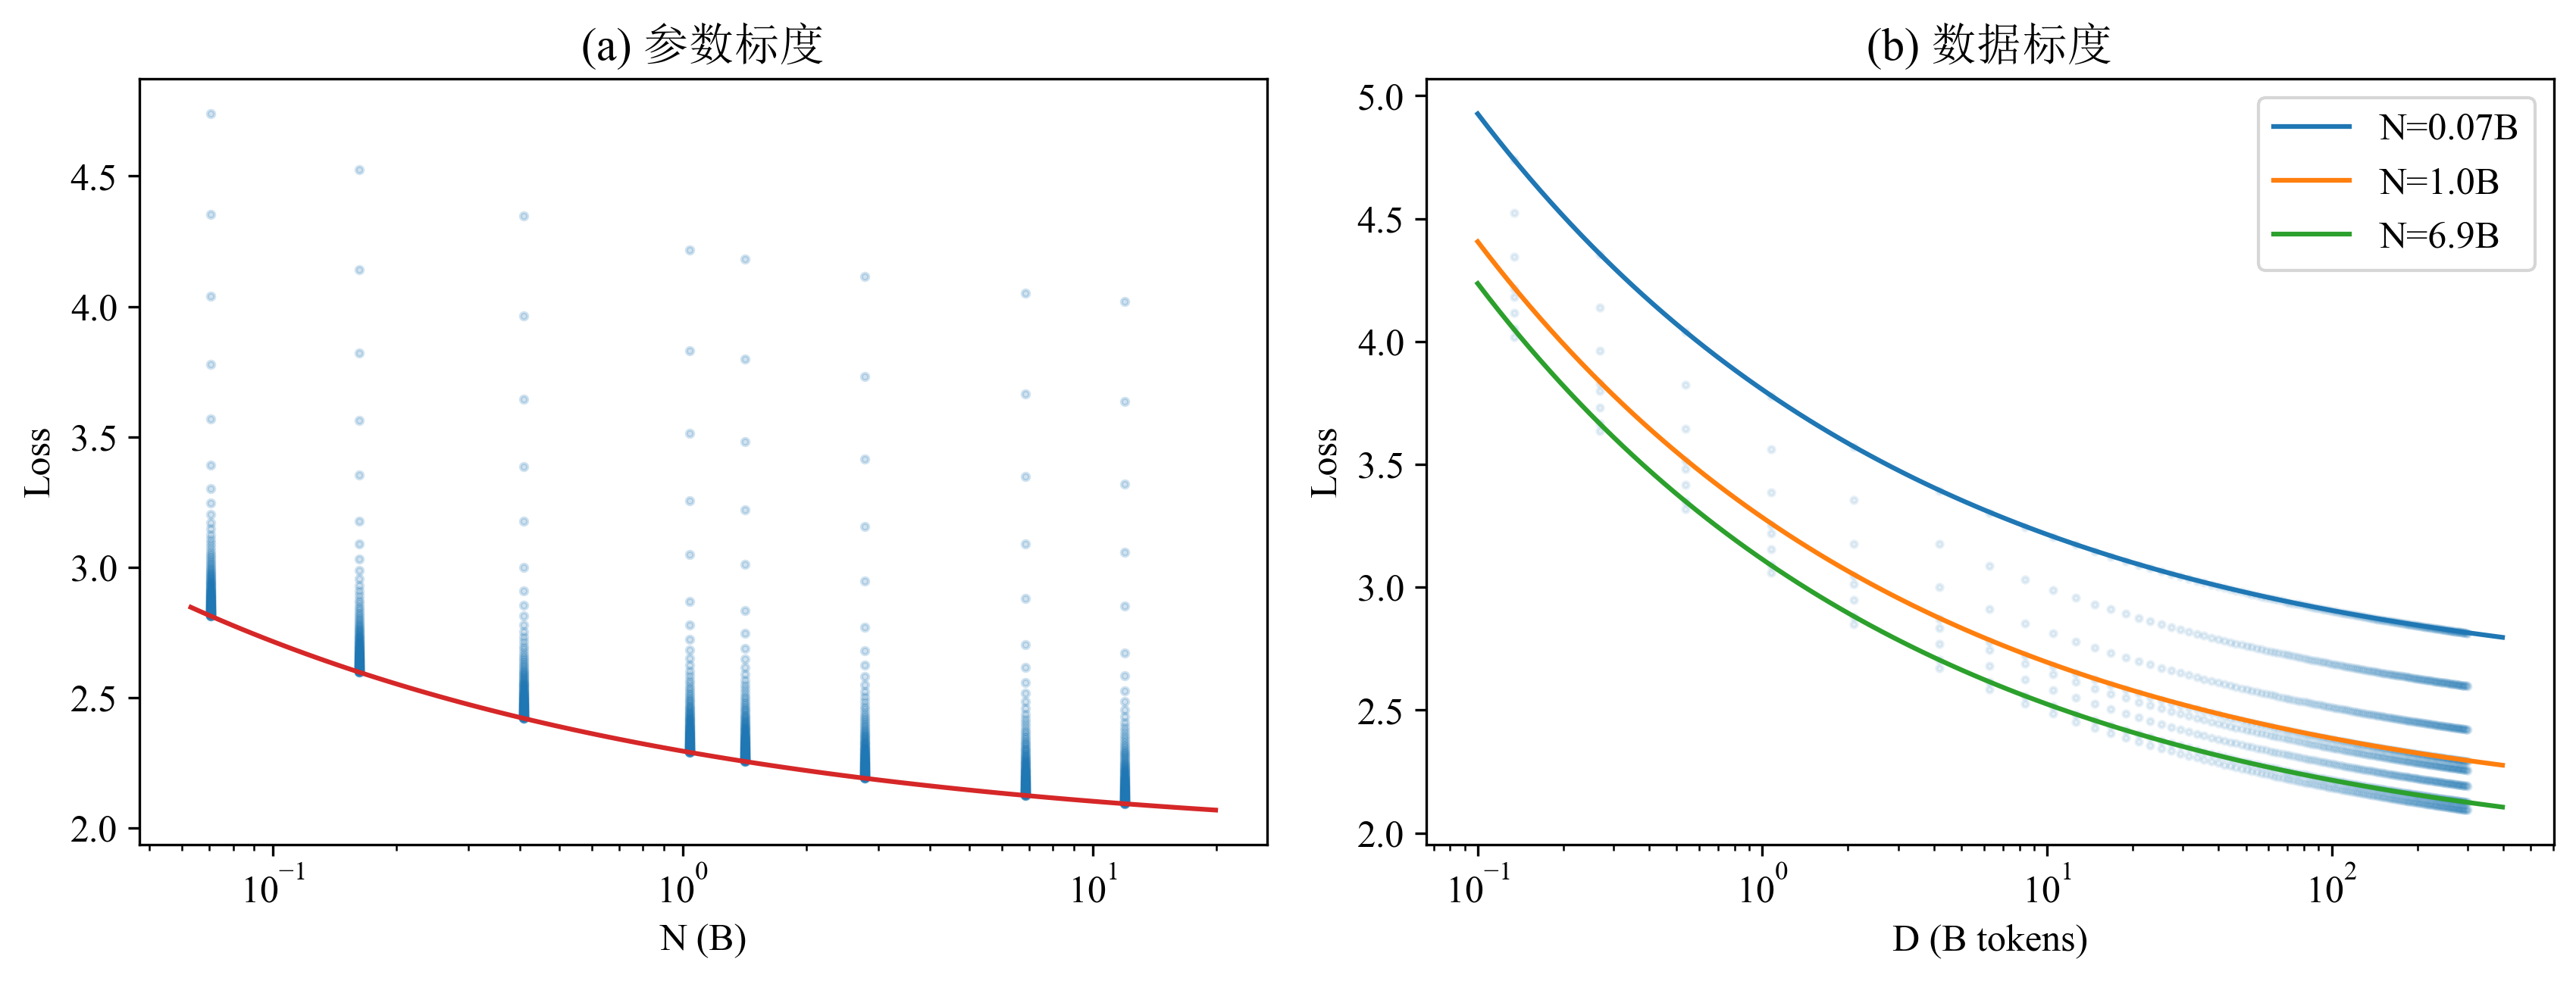

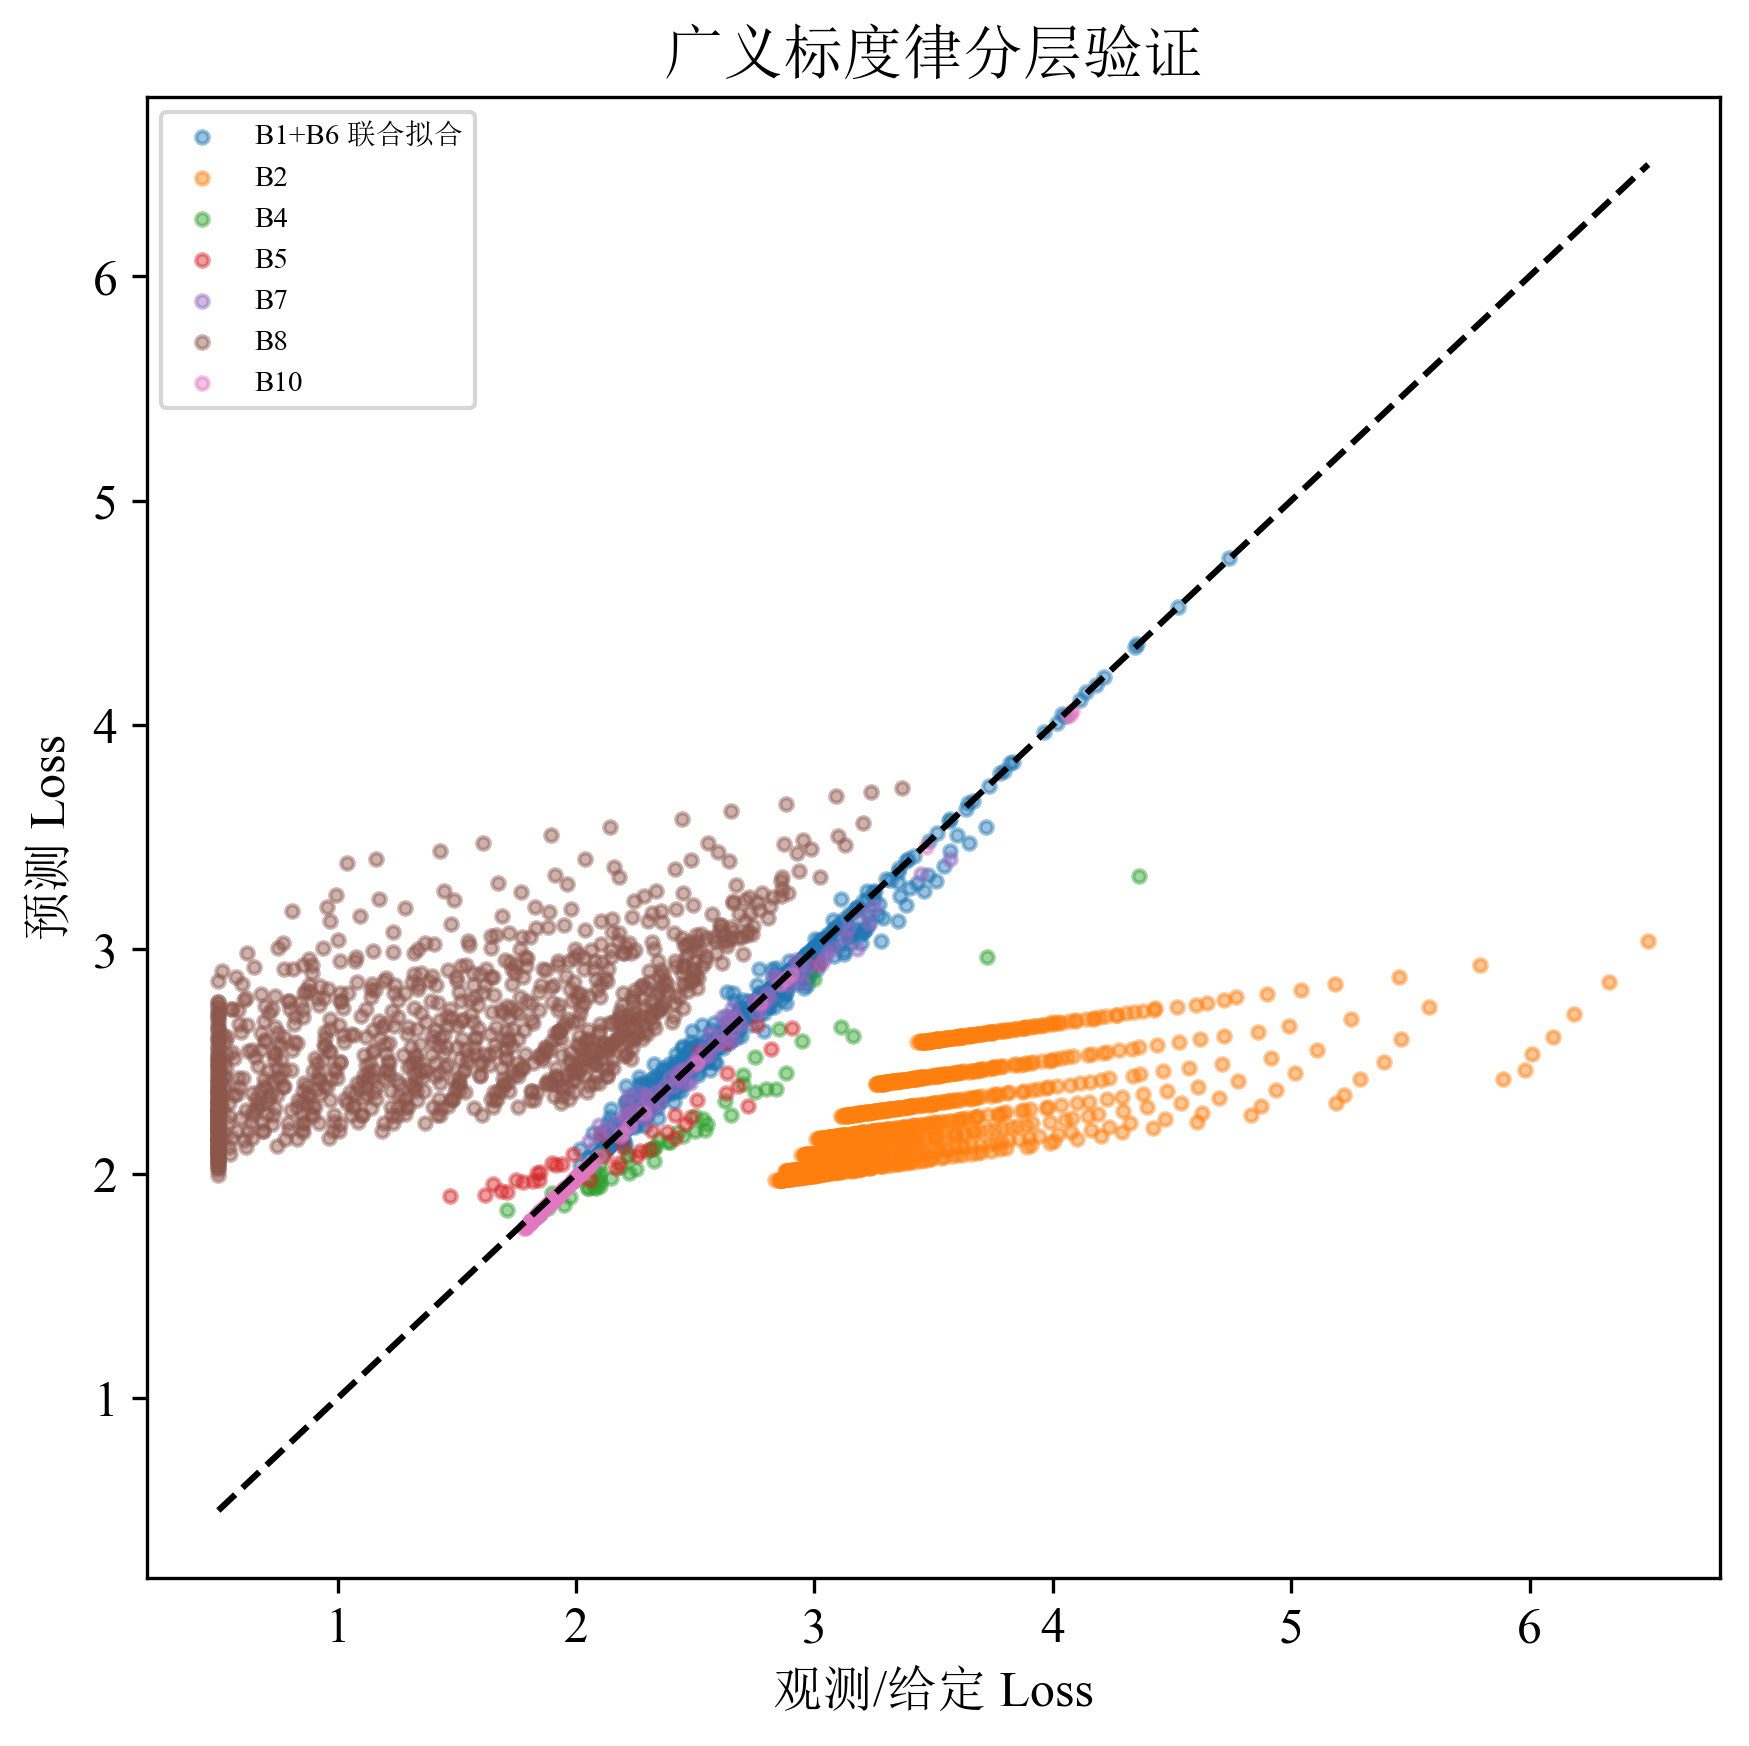

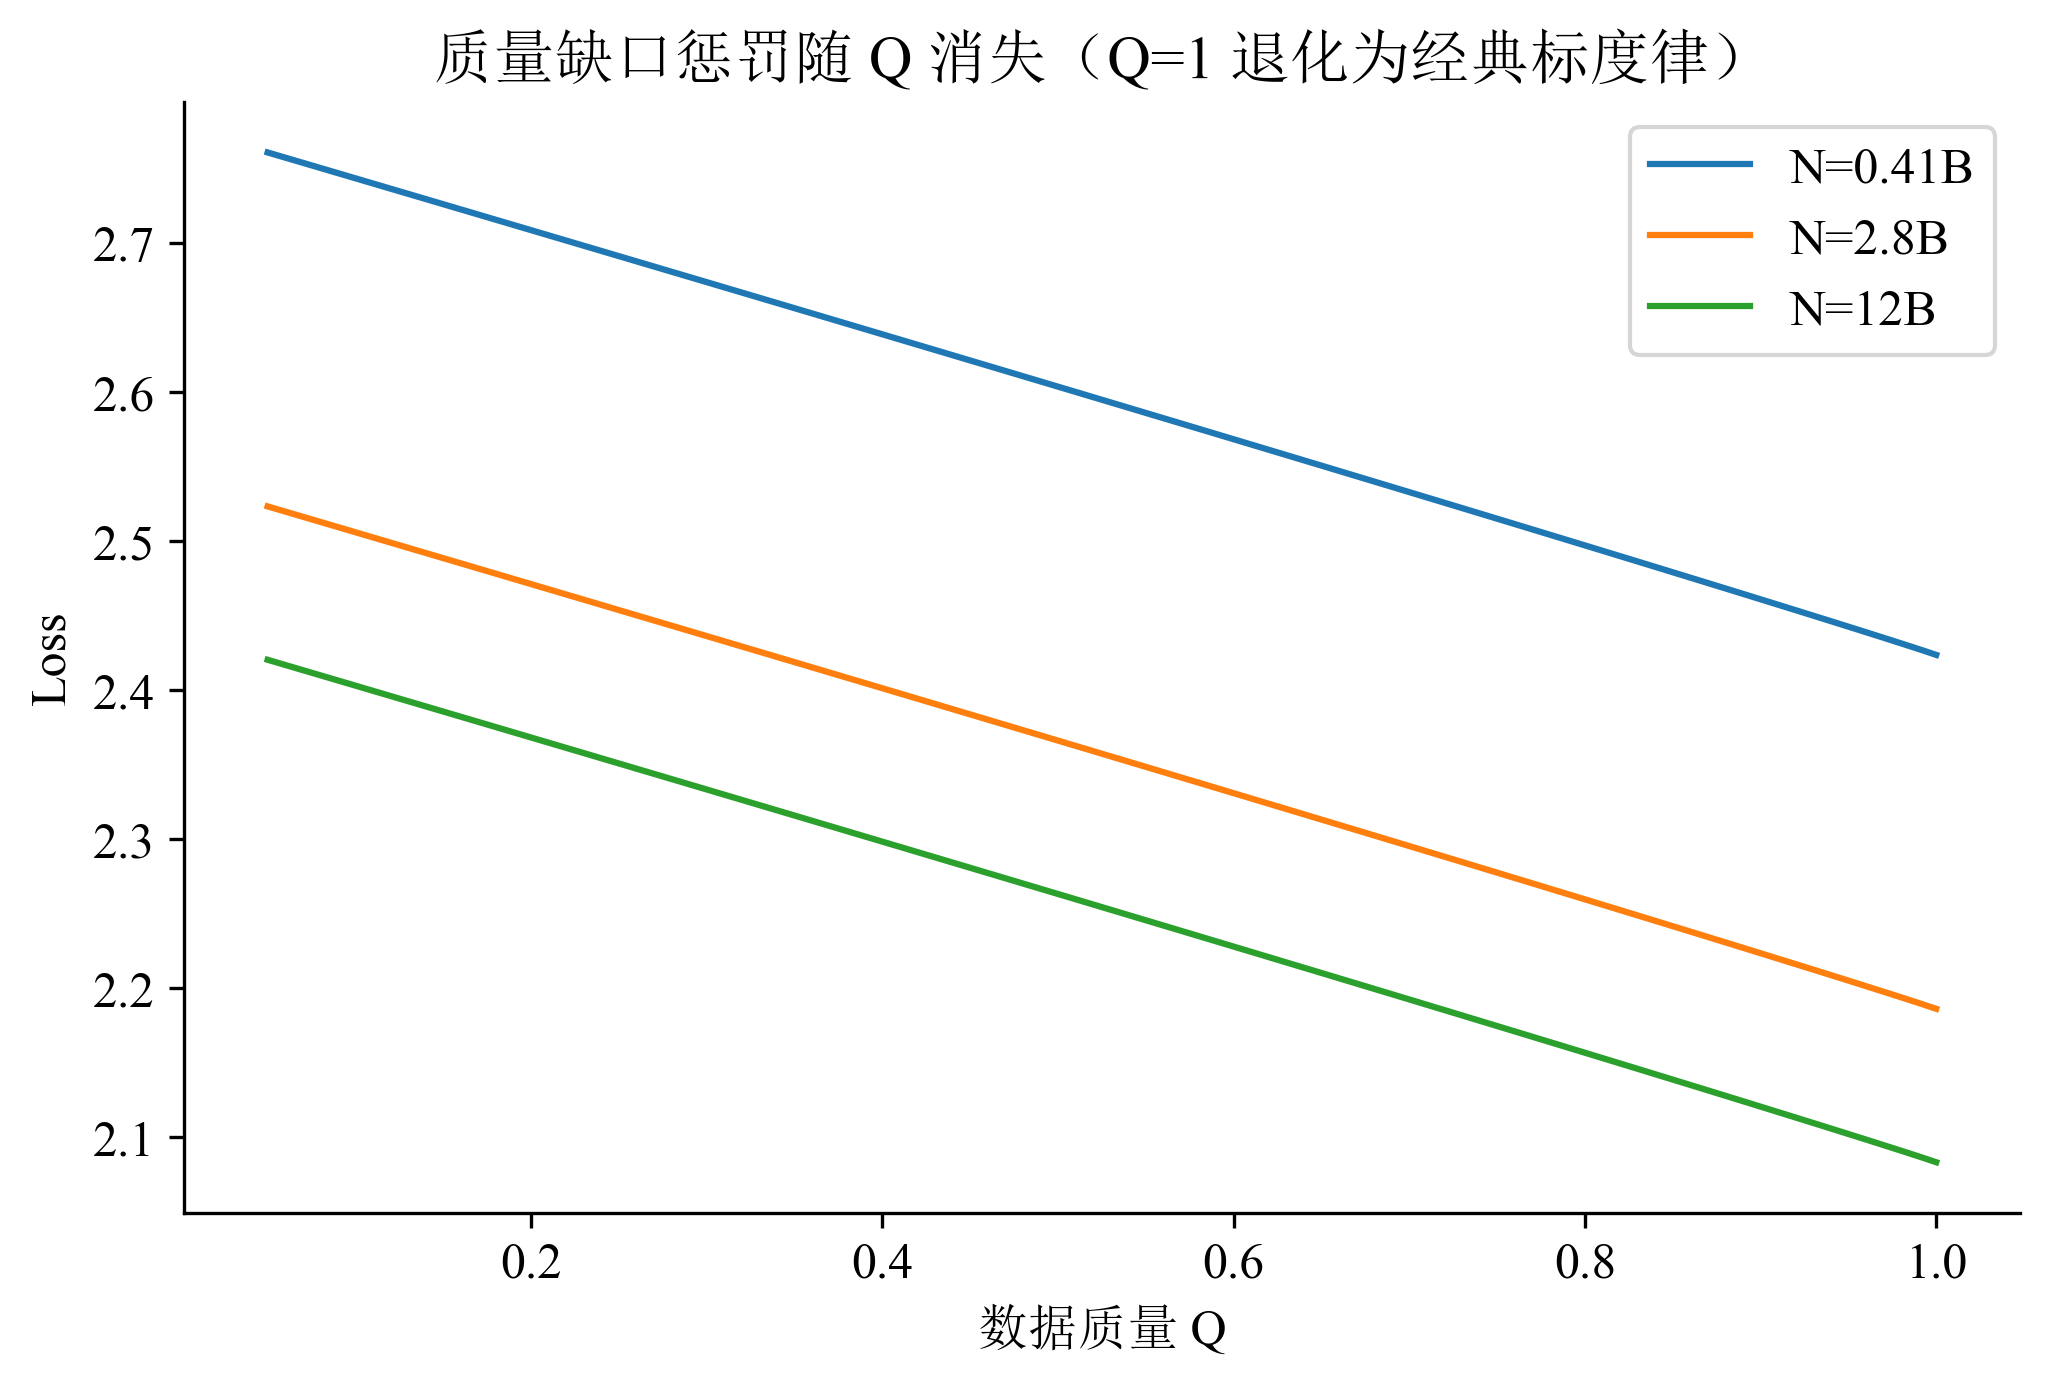

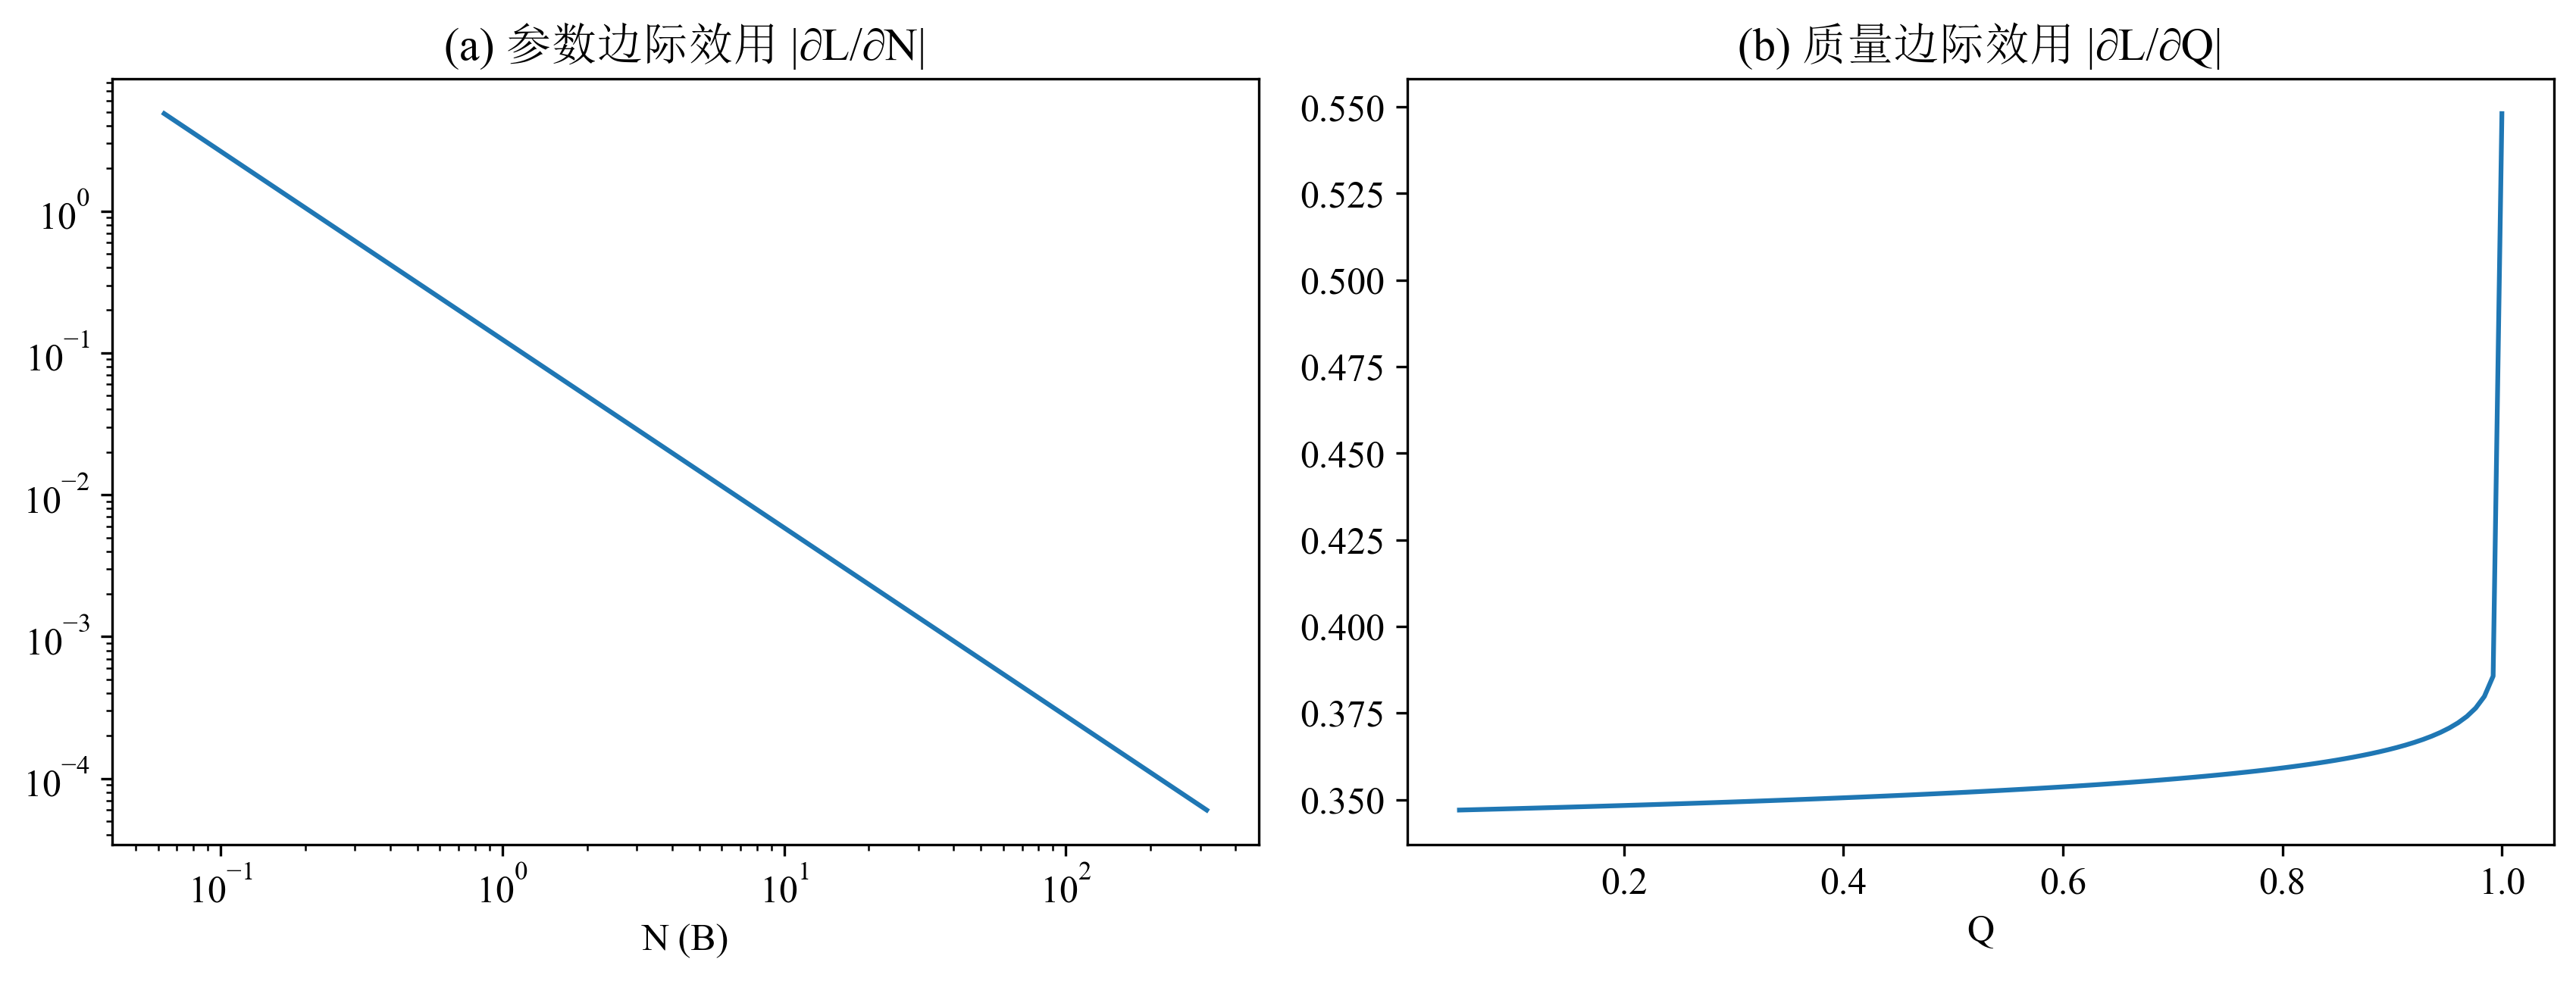

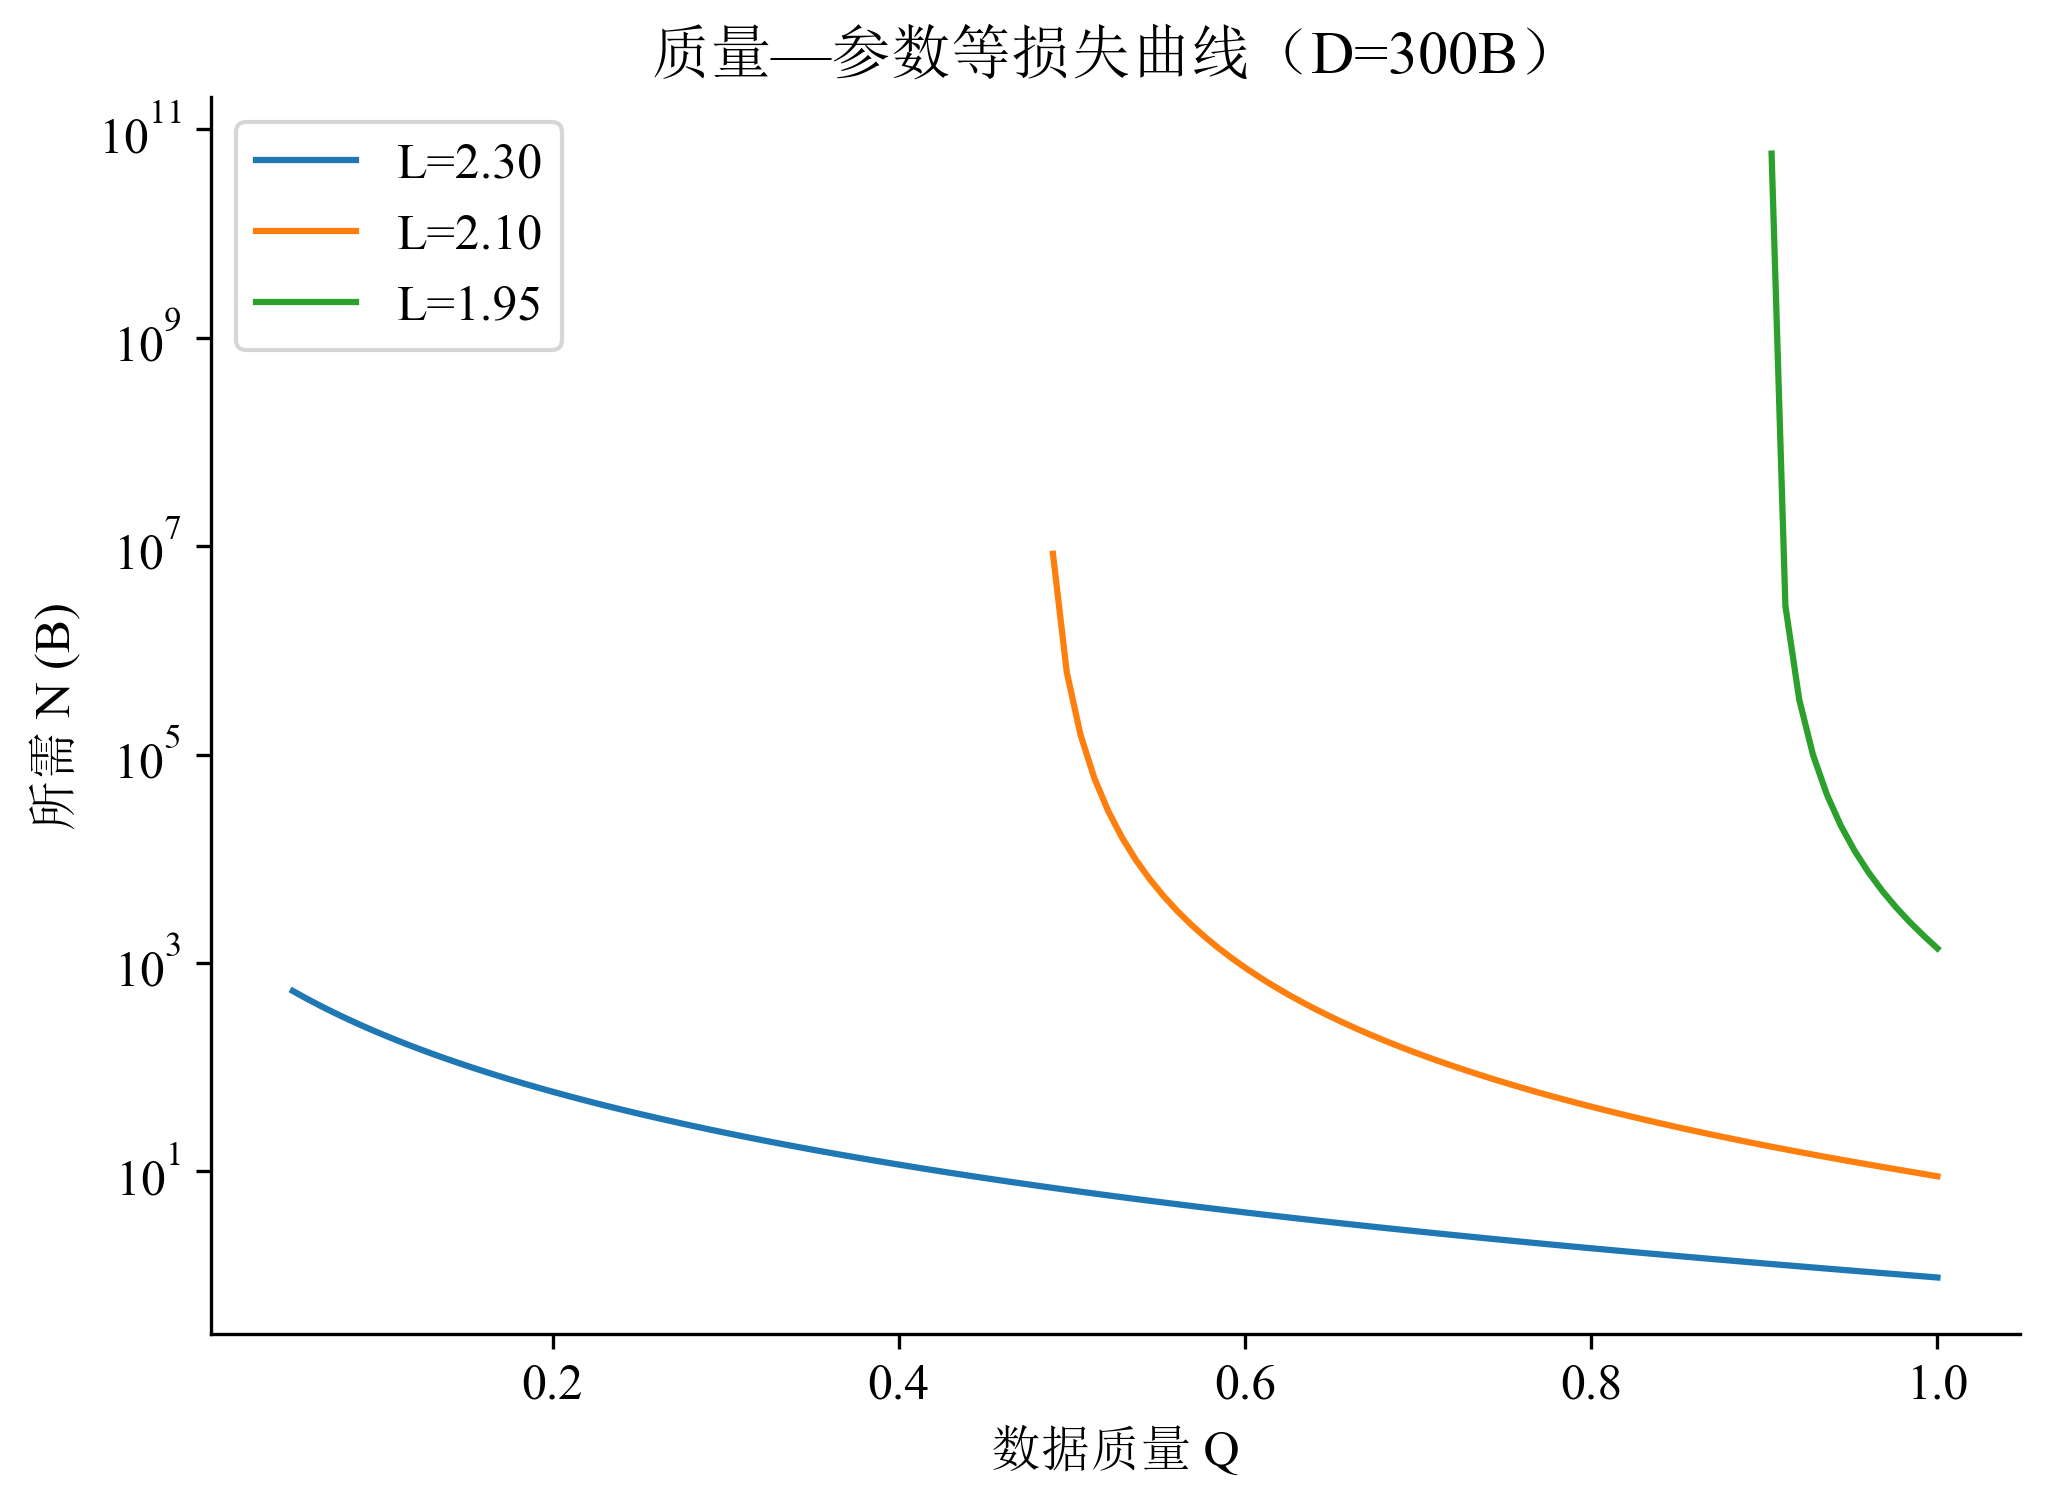

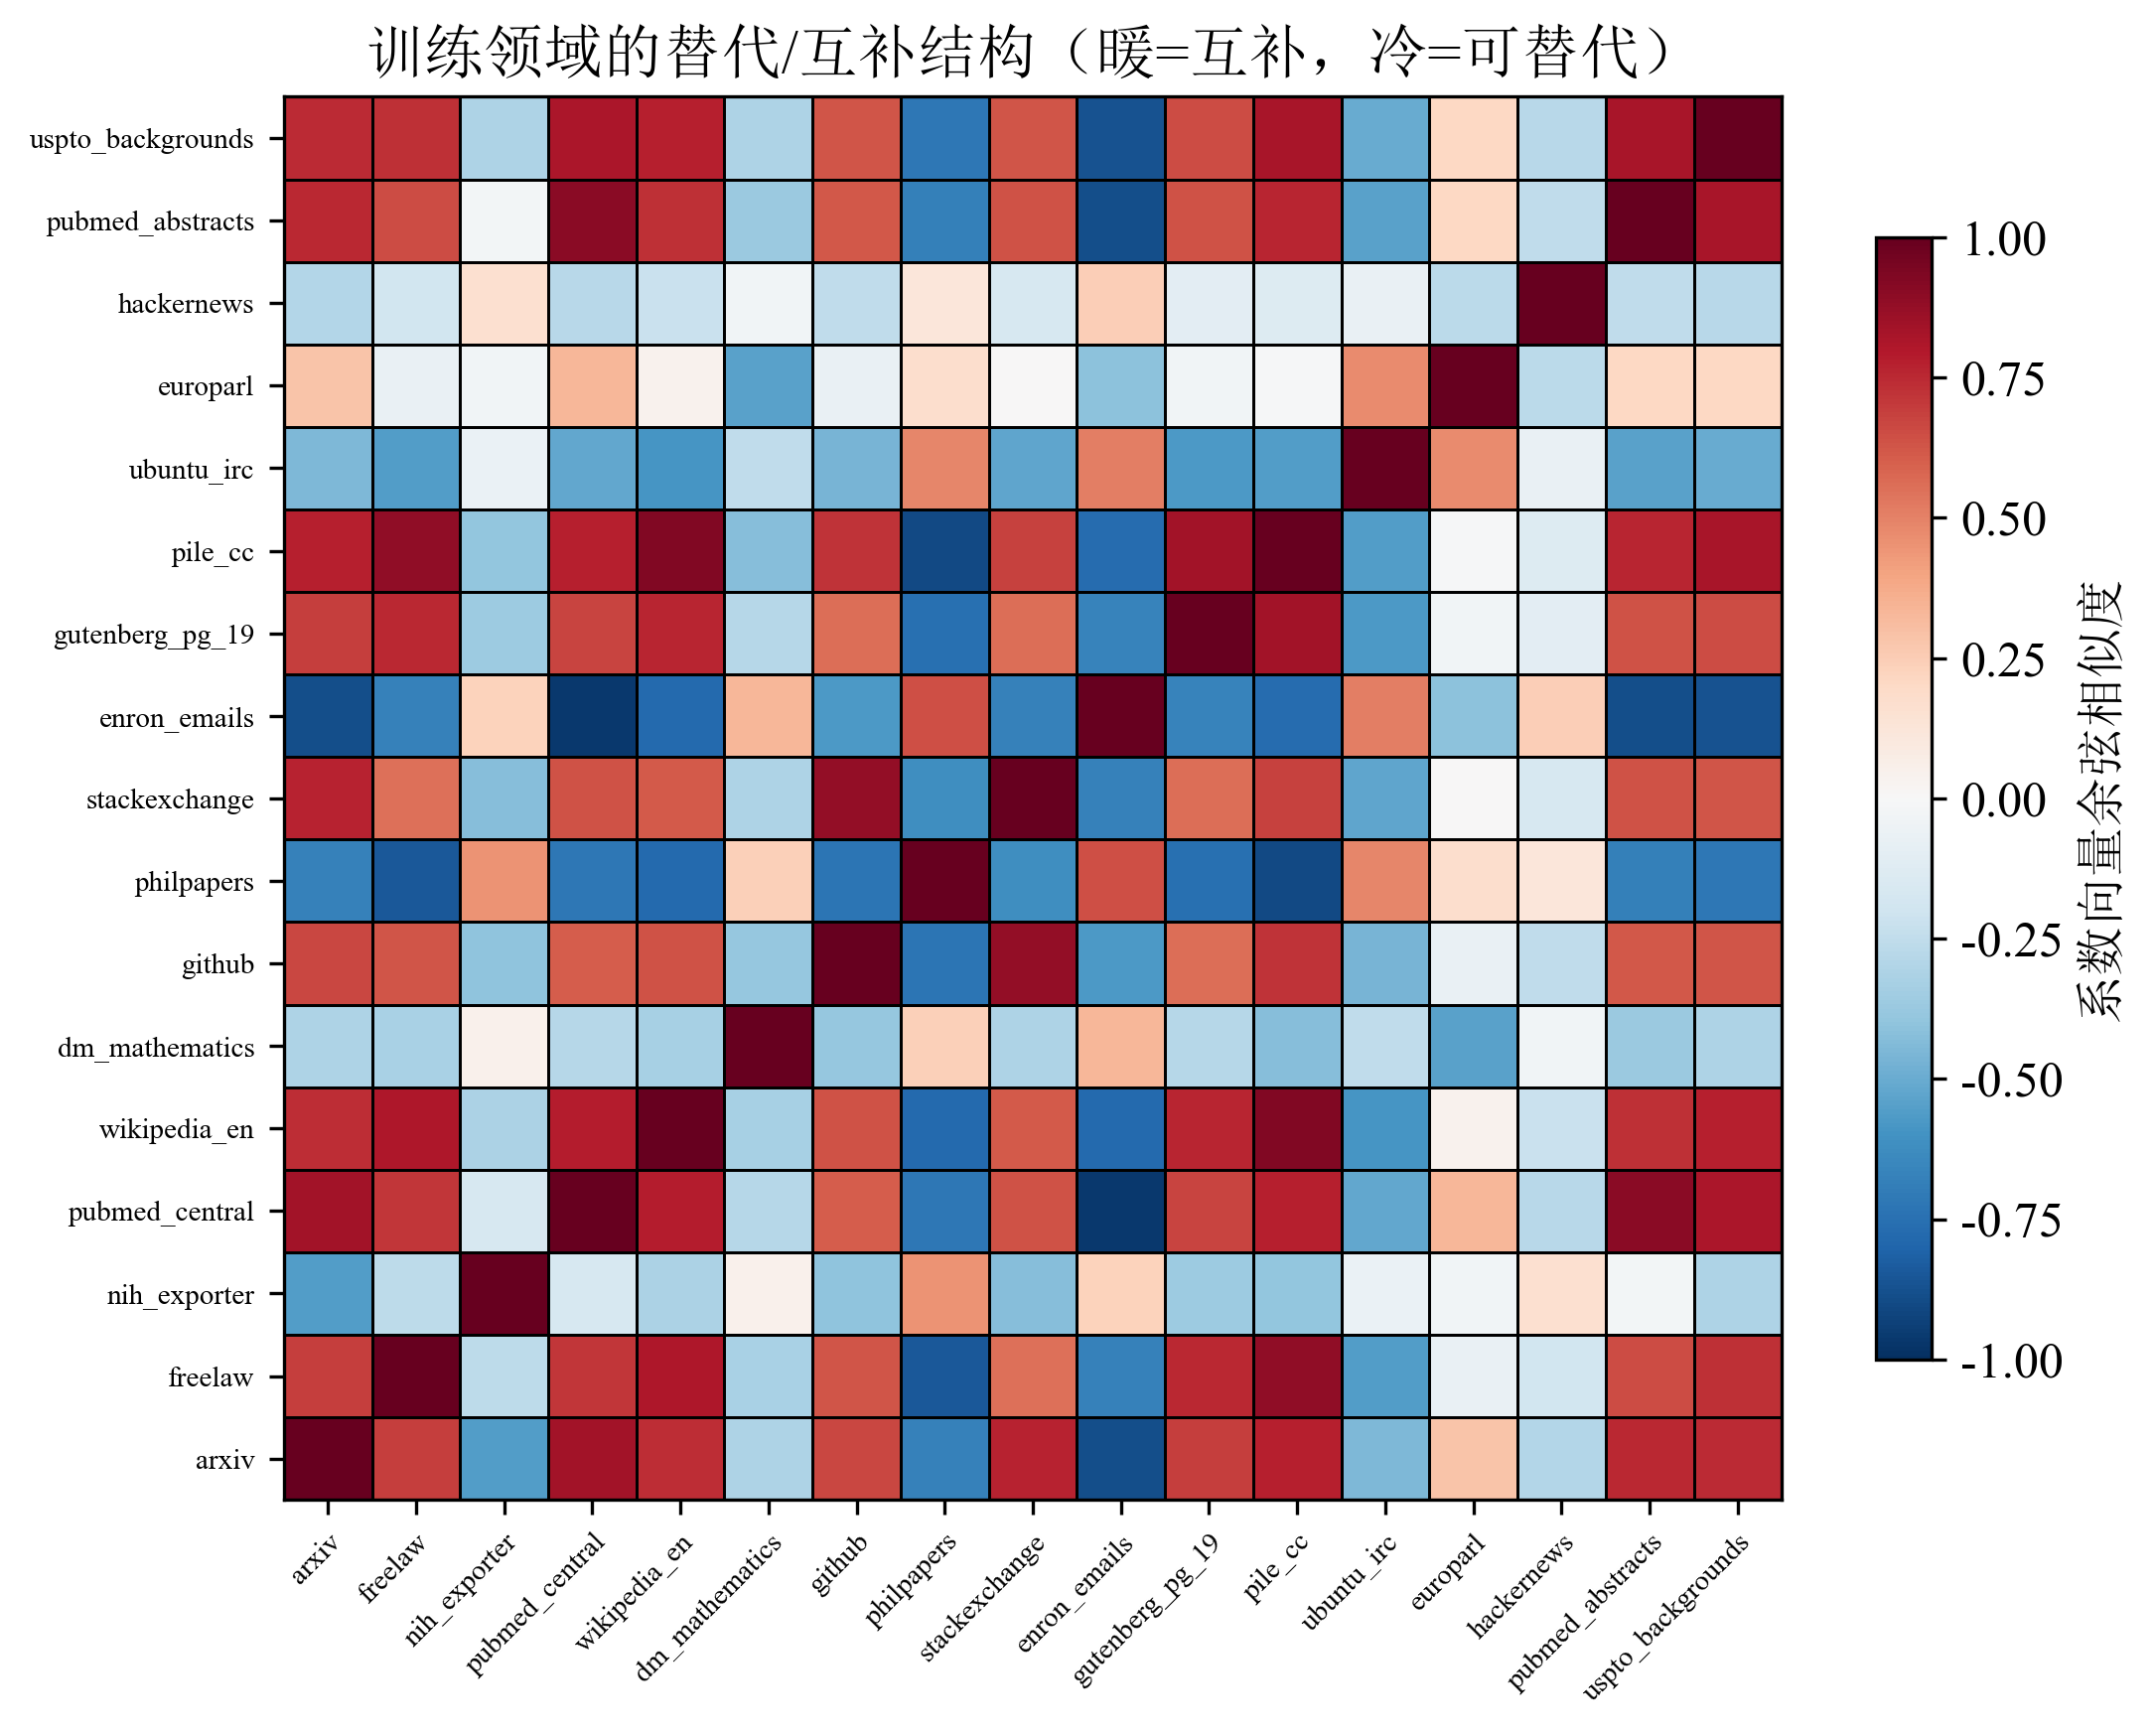

In [11]:
# ============ 9. 绘图 ============
plt.rcParams['font.size'] = 12
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
axes[0].scatter(N_p, L_p, s=5, alpha=.2)
ns = np.logspace(-1.2, 1.3, 100)
axes[0].plot(ns, classic(r0.x, ns, np.full_like(ns, 300)), color='#d62728')
axes[0].set_xscale('log'); axes[0].set_xlabel('N (B)'); axes[0].set_ylabel('Loss')
axes[0].set_title('(a) 参数标度')
for n in [.07, 1., 6.9]:
    ds = np.logspace(-1, 2.6, 100)
    axes[1].plot(ds, classic(r0.x, np.full_like(ds, n), ds), label='N=%sB' % n)
axes[1].scatter(D_p, L_p, s=4, alpha=.1)
axes[1].set_xscale('log'); axes[1].set_xlabel('D (B tokens)'); axes[1].set_ylabel('Loss')
axes[1].set_title('(b) 数据标度'); axes[1].legend()
fig.tight_layout(); save_fig(fig, '图1_经典标度律拟合')

fig, ax = plt.subplots(figsize=(6, 6))
for name, y, ph in [('B1+B6 联合拟合', L_all, Lhat)] + pred_sets:
    ax.scatter(y, ph, s=9, alpha=.45, label=name)
lo = min(np.min(x[1]) for x in [('', L_all, Lhat)] + pred_sets)
hi = max(np.max(x[1]) for x in [('', L_all, Lhat)] + pred_sets)
ax.plot([lo, hi], [lo, hi], 'k--')
ax.set_xlabel('观测/给定 Loss'); ax.set_ylabel('预测 Loss')
ax.set_title('广义标度律分层验证'); ax.legend(fontsize=7)
fig.tight_layout(); save_fig(fig, '图2_广义标度律验证')

Qg = np.linspace(.05, 1, 120)
fig, ax = plt.subplots(figsize=(7, 4.8))
for n in [.41, 2.8, 12]:
    ax.plot(Qg, fn_best(r1x, n, 300, Qg), label='N=%sB' % n)
ax.set_xlabel('数据质量 Q'); ax.set_ylabel('Loss')
ax.set_title('质量缺口惩罚随 Q 消失（Q=1 退化为经典标度律）')
ax.legend(); despine(ax); fig.tight_layout(); save_fig(fig, '图3_质量边际影响')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
Ng = np.logspace(-1.2, 2.5, 100)
axes[0].plot(Ng, alpha * A * Ng ** (-alpha - 1))
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_title('(a) 参数边际效用 |∂L/∂N|'); axes[0].set_xlabel('N (B)')
axes[1].plot(Qg, Cq * gamma * (1 - Qg + 1e-9) ** (gamma - 1))
axes[1].set_title('(b) 质量边际效用 |∂L/∂Q|'); axes[1].set_xlabel('Q')
fig.tight_layout(); save_fig(fig, '图4_边际效用对比')

fig, ax = plt.subplots(figsize=(7, 5.2))
for target in [2.30, 2.10, 1.95]:
    rhs = target - E - B * 300.0 ** (-beta) - Cq * (1 - Qg) ** gamma
    Ns2 = np.where(rhs > 0, (A / np.maximum(rhs, 1e-12)) ** (1 / alpha), np.nan)
    ax.plot(Qg, Ns2, label='L=%.2f' % target)
ax.set_yscale('log'); ax.set_xlabel('数据质量 Q'); ax.set_ylabel('所需 N (B)')
ax.set_title('质量—参数等损失曲线（D=300B）'); ax.legend()
despine(ax); fig.tight_layout(); save_fig(fig, '图5_质量参数替代')

fig, ax = plt.subplots(figsize=(7.5, 6))
mesh = safe_heatmap(ax, sim, row_labels=domains, col_labels=domains, cmap='RdBu_r', fontsize=7)
mesh.set_clim(-1, 1)
cb = fig.colorbar(mesh, ax=ax, shrink=0.8); cb.set_label('系数向量余弦相似度')
ax.set_title('训练领域的替代/互补结构（暖=互补，冷=可替代）')
fig.tight_layout(); save_fig(fig, '图6_领域替代互补')

print('\n===== 问题二求解完成 =====')
print('经典 R2=%.8f，留出 R2=%.8f；广义 R2=%.4f；替代率 dN/dQ=%.3f B/单位质量'
      % (R2_cls, hold['留出R2'], R2_gen, subst))


## 结论解读与本问小结

1. **方向审计的结论很关键**：控制 $N,D$ 后 B6/B7 的组内相关为 $-0.925/-0.918$，说明 `Q_score` **就是质量指标（越大越好）**，应与问题一"越高越好"统一口径。若判成"难度"再取补，整个质量项符号就反了。
2. **B8 不能并入拟合**：其方向与 B6/B7 相反（$+0.995$），且最小损失 0.50 低于模型不可约损失下限 1.656，属口径异常，只作可信度边界警示。B2（Cerebras）的 MAPE 达 33.7%，只作定性参考。
3. **选定形式为加性质量缺口** $L=E+AN^{-\alpha}+BD^{-\beta}+C(1-Q)^{\gamma}$：$Q=1$ 时精确退化为经典形式，且 $\lim_{N,D\to\infty}L=E+C(1-Q)^{\gamma}\ge E$，物理含义是"数据质量决定可达的损失下限"。联合拟合 $R^2=0.9896$、MAPE 0.66%。
4. **经典标度律在 B1 上 $R^2=0.9999998$，但要如实说明**：该附件残差标准差仅 $1.5\times10^{-4}$、损失标准差 0.34，几乎是 $(N,D)$ 的无噪声函数，所以此处的极高精度只能证明形式自洽；真正的泛化证据是 B4（$r=0.975$、MAPE 8.8%）与 B5（$r=0.910$、MAPE 8.0%）。
5. **B3 轨迹验证**：8 条轨迹内拟合出的 $D$ 幂指数为 $-0.2806\sim-0.2803$，与主拟合 $-\beta=-0.2799$ 高度一致，是一次独立验证。
6. **替代关系**：参考点 $N=1$B、$D=100$B、$Q=0.6$ 处 $\varepsilon_Q=-0.084$ 强于 $\varepsilon_N=-0.049$；替代率 $\mathrm dN/\mathrm dQ=2.844$ B/单位质量（即质量 +0.1 ≈ 参数 +0.28B），且在 $N=12$B 处升到 76.8（质量 +0.1 ≈ 参数 +7.68B）——**规模越大，用质量换规模越划算**。